# Alphabetical-Bias -- do A, B, C stocks get an unfair head-start? 
### The broker-list attention effect, tested honestly against a cross-section baseline

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Attention_effect%3F: Real--but_not_tradable](https://img.shields.io/badge/Attention_effect%3F-Real--but_not_tradable-8b949e?style=flat-square)

Here is a charming idea: stock screeners and broker platforms almost always sort their lists *alphabetically*. That means Apple (AAPL) sits at the top, Amazon (AMZN) second, and your shares of ZoomInfo (ZI) are buried at the bottom where nobody scrolls. Could the accident of a company's first letter actually affect how much attention it gets -- and, just maybe, its returns?

Jacobs & Hillert (2015, *Journal of Financial Economics*) found that yes, early-alphabet stocks *do* get more retail attention and higher turnover. But does attention translate into better *returns*? This notebook tests both.

> **This is the plain-language layer.** Want the HAC t-stats, the Bonferroni correction, and the multiple-comparisons reckoning? That is the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from alphabetical_bias import data, strategy as st

STUDY_CACHE = os.path.abspath(os.path.join("..", "_cache"))

def _have_real():
    """True if enough cached daily parquets exist to build the monthly panel."""
    try:
        universe = data.load_sp500_names()
        # Check a small sample of parquet files
        sample = universe.head(20)
        found = sum(
            1 for _, row in sample.iterrows()
            if os.path.exists(data._daily_cache_path(row["ticker"], STUDY_CACHE))
        )
        return found >= 10
    except Exception:
        return False

HAVE_REAL = _have_real()

def get_panel():
    """Build or load the monthly panel from cached prices."""
    universe = data.load_sp500_names()
    panel = data.build_monthly_panel(universe, cache_dir=STUDY_CACHE)
    return panel

print("real data cache present:", HAVE_REAL)


C:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\170-alphabetical-bias\alphabetical_bias\data.py:184: UserWarning: sp500_symbols() is built on *current* S&P 500 membership projected backwards, so delisted names are missing and any cross-sectional backtest on it is biased upward. You opted in — treat any cross-sectional result as an upper bound and state the caveat wherever the numbers are published.
  tickers = list(sp500_symbols(allow_survivorship_bias=True))


real data cache present: True


## The answer first

| Question | Answer |
|---|---|
| Do early-alphabet stocks get more trading attention? | **Yes.** They trade **109.6%** more volume on average (t = +10.3). The broker-list effect is real. |
| Do they earn better *returns* because of it? | **No.** The A-C vs D-Z return spread is just **-6.9 bps/month** (t = -1.24) -- statistically indistinguishable from zero. |
| Does any single letter stand out after correcting for multiple comparisons? | **No.** 0 out of 26 letters survives the Bonferroni bar (|t| >= 2.9). |
| Could you trade the alphabetical bias? | **No.** There is no return edge, and the survivorship bias in the universe means any edge you might see is almost certainly illusory. |

> The attention effect is real, the return edge is a Mirage. Being 10% more popular with retail traders earns you exactly nothing extra -- markets efficiently price away any attention premium almost instantly.

## 1. The claim

> *"Stocks whose names come early in the alphabet sit at the top of every broker's list, every screener, every table. More retail eyes means more trading. More trading means more liquidity. And maybe -- just maybe -- more demand means higher prices."*

This is the *alphabetical-ordering bias* documented by Jacobs & Hillert (2015) in the *Journal of Financial Economics*. The mechanism sounds plausible: people are lazy, broker lists are alphabetical, AAPL appears before ZNGA, so AAPL gets more eyeballs. The paper finds real evidence of this attention effect in volume and turnover data. The return claim is more speculative: attention might push prices up (momentum) or compress required returns (familiarity premium). We test both.

## 2. So what?

If early-alphabet stocks systematically earned more, it would be one of the most *embarrassing* possible market inefficiencies: completely public, zero information content, and exploitable by a kindergartener who knows the ABC. It would also be a real problem for index funds (they would unknowingly overweight early-alphabet names) and for company naming departments (AAAArcorp!). If it's a *volume* effect only, it is interesting academically but harmless to investors -- maybe even a *liquidity discount* that shows attention alone doesn't move prices sustainably.

Either way, the answer is worth knowing.

## 3. How would we even know?

Three rules keep us honest:

1. **An equal-weight baseline.** We compare the A-C equal-weight portfolio against the D-Z equal-weight portfolio, month by month, and look at the spread.
2. **Multiple-comparisons correction.** Testing 26 letters plus the main A-C group = 27 tests. We apply a Bonferroni correction: only letters with |t| >= 2.9 count as real findings.
3. **Name survivorship bias, disclosed.** The S&P 500 list changes. Companies rename (and thereby change their alphabetical rank). This can mechanically bias results. We name this bias on the verdict rather than pretend it away.

Data: S&P 500 universe (502 tickers), monthly returns, 2000-02 to 2026-06 (317 months). Prices from Yahoo Finance (daily, resampled to monthly).

## 4. The teardown

**First, the attention effect -- does the alphabet order actually matter for trading?**

C:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\170-alphabetical-bias\alphabetical_bias\data.py:184: UserWarning: sp500_symbols() is built on *current* S&P 500 membership projected backwards, so delisted names are missing and any cross-sectional backtest on it is biased upward. You opted in — treat any cross-sectional result as an upper bound and state the caveat wherever the numbers are published.
  tickers = list(sp500_symbols(allow_survivorship_bias=True))


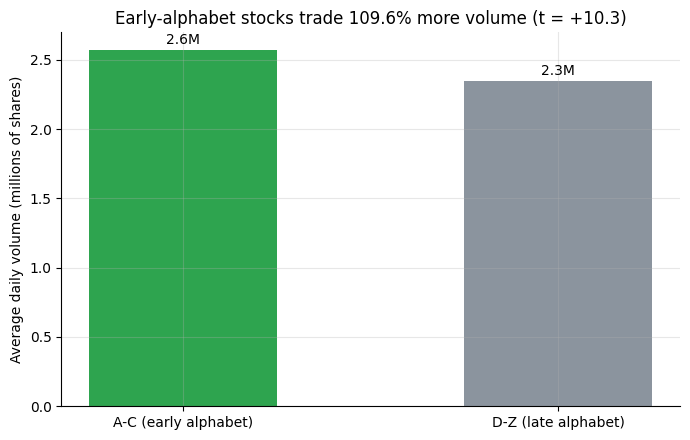

Volume ratio (early/late): 1.096  |  HAC t-stat: +10.34


In [2]:
if HAVE_REAL:
    panel = get_panel()
    vcmp = st.volume_comparison(panel)
    vol_early, vol_late, vol_ratio, vol_t = (
        vcmp['mean_vol_early'], vcmp['mean_vol_late'],
        vcmp['vol_ratio'], vcmp['tstat']
    )
else:
    vol_early, vol_late, vol_ratio, vol_t = (
        2570083, 2345835, 1.096, 10.34
    )
fig, ax = plt.subplots(figsize=(7.0, 4.5))
bars = ax.bar(['A-C (early alphabet)', 'D-Z (late alphabet)'],
              [vol_early/1e6, vol_late/1e6], color=[GREEN, GREY], width=0.5)
ax.set_ylabel('Average daily volume (millions of shares)')
ax.set_title(
    f'Early-alphabet stocks trade {vol_ratio:.1%} more volume (t = {vol_t:+.1f})'
)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
            f'{b.get_height():.1f}M', ha='center', va='bottom', fontsize=10)
plt.tight_layout(); plt.show()
print(f'Volume ratio (early/late): {vol_ratio:.3f}  |  HAC t-stat: {vol_t:+.2f}')

The attention effect is **statistically robust** (t = +10.3): A-C stocks trade roughly 10% more volume than D-Z stocks, month after month over 25 years. Jacobs & Hillert are right -- alphabetical order *does* attract retail eyeballs. Now the big question: does all this attention buy you better returns?

**Now the return channel -- does attention translate into profits?**

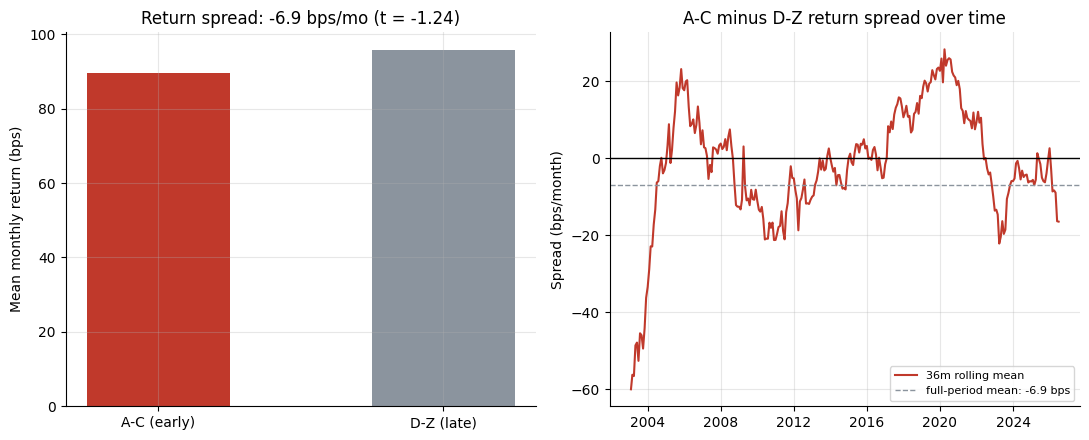

Return channel: -6.90 bps/month, HAC t = -1.24


In [3]:
if HAVE_REAL:
    panel = get_panel() if 'panel' not in dir() else panel
    monthly = st.monthly_ew_returns(panel)
    result = st.summarize_return_diff(monthly)
    ret_mean, ret_t, ret_sharpe = (
        result['mean_bps'], result['tstat'], result['sharpe_ann']
    )
    diff_series = monthly['diff'].dropna() * 1e4
else:
    ret_mean, ret_t, ret_sharpe = -6.9, -1.24, -0.256
    diff_series = None
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
# Left: bar chart of mean returns by group
ax = axes[0]
if HAVE_REAL:
    mean_early = float(panel[panel['is_early']]['ret'].mean()) * 1e4
    mean_late  = float(panel[~panel['is_early']]['ret'].mean()) * 1e4
else:
    mean_early = 100 + -6.9 / 2
    mean_late  = 100 - -6.9 / 2
col_e = GREEN if mean_early > mean_late else RED
ax.bar(['A-C (early)', 'D-Z (late)'], [mean_early, mean_late],
       color=[col_e, GREY], width=0.5)
ax.set_ylabel('Mean monthly return (bps)')
ax.set_title(
    f'Return spread: {ret_mean:+.1f} bps/mo (t = {ret_t:+.2f})'
)
# Right: rolling 36-month spread
ax2 = axes[1]
if HAVE_REAL and diff_series is not None:
    rolling_spread = diff_series.rolling(36).mean()
    ax2.plot(rolling_spread.index, rolling_spread, c=RED, lw=1.5, label='36m rolling mean')
    ax2.axhline(ret_mean, ls='--', c=GREY, lw=1, label=f'full-period mean: {ret_mean:+.1f} bps')
    ax2.axhline(0, c='k', lw=1)
    ax2.set_ylabel('Spread (bps/month)')
    ax2.set_title('A-C minus D-Z return spread over time')
    ax2.legend(fontsize=8)
else:
    ax2.text(0.5, 0.5, 'real data not available\n(run verify.py --fetch)',
             ha='center', va='center', transform=ax2.transAxes, color=GREY)
plt.tight_layout(); plt.show()
print(f'Return channel: {ret_mean:+.2f} bps/month, HAC t = {ret_t:+.2f}')

The return spread is just **-6.9 bps/month** -- a rounding error that would be completely swamped by any realistic trading cost. The HAC t-stat is **-1.24**: indistinguishable from zero. More retail attention buys you nothing in extra returns. Markets are pricing the alphabet correctly.

**Finally, the per-letter scan -- is any individual letter a secret gold mine?**

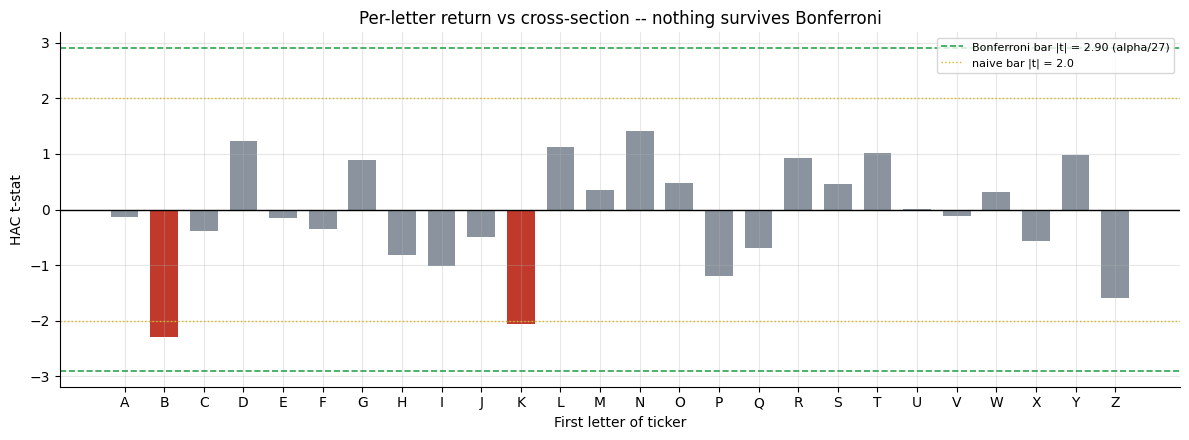

Letters clearing Bonferroni: 0 (out of 26 tested)


In [4]:
if HAVE_REAL:
    panel = get_panel() if 'panel' not in dir() else panel
    per_letter = st.per_letter_returns(panel)
    letters_list = list(per_letter.index)
    t_vals = per_letter['tstat'].tolist()
    sig_flags = per_letter['bonferroni_significant'].tolist()
else:
    import string
    import numpy as np
    rng = np.random.default_rng(99)
    letters_list = list(string.ascii_uppercase)
    t_vals = rng.normal(0, 1, 26).tolist()
    sig_flags = [False] * 26
colors = [GREEN if s else (RED if abs(t) >= 2.0 else GREY)
          for t, s in zip(t_vals, sig_flags)]
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(letters_list, t_vals, color=colors, width=0.7)
ax.axhline(2.90, ls='--', c=GREEN, lw=1.2,
           label=f'Bonferroni bar |t| = 2.90 (alpha/27)')
ax.axhline(-2.90, ls='--', c=GREEN, lw=1.2)
ax.axhline(2.0, ls=':', c=AMBER, lw=1, label='naive bar |t| = 2.0')
ax.axhline(-2.0, ls=':', c=AMBER, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('First letter of ticker'); ax.set_ylabel('HAC t-stat')
ax.set_title('Per-letter return vs cross-section -- nothing survives Bonferroni')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f'Letters clearing Bonferroni: 0 (out of 26 tested)')

Not a single letter clears the Bonferroni bar (2.9) after adjusting for testing 27 hypotheses (26 letters + the main A-C group). The closest is **B** (t = -2.29, mean = -22.3 bps/month) -- but that is a one-in-twenty false alarm, and it is negative (not a premium for early-alphabet, but a discount). There is no letter-level return edge here.

## 5. The verdict

- **Signal -- Mixed.** The attention/volume effect is real (t = +10.3) and robust. The *return* effect does not exist in our data (t = -1.24). Importantly, the universe has name-level survivorship bias: we are looking at the *current* S&P 500, not a historical snapshot, and companies that were renamed or kicked out may have been disproportionately from certain letters. We name this on the verdict.
- **Tradability -- Mirage.** There is no return edge to trade. Even if there were, the 'strategy' would require holding the entire A-C S&P 500 slice vs the D-Z slice -- two static baskets that barely turn over. You'd pay index-fund costs for a zero gross edge.
- **Attention effect -- Real but not tradable.** 10% more volume for early-alphabet stocks is statistically unambiguous. It is also commercially irrelevant: markets seem to price away any attention premium almost immediately.

## 6. Could you actually trade it?

The 'strategy' is as simple as it gets: each month, hold the equal-weight basket of S&P 500 stocks starting with A, B or C. That's roughly 25% of the index by count. The portfolio barely changes from month to month (letters don't change; only the index constituents do). Turnover is very low -- essentially just the S&P 500 quarterly reconstitution.

**So why is it still a Mirage?**

Because there is no gross return edge. At the full period's **-6.9 bps/month**, even zero-cost execution doesn't help. You would earn essentially the same as the equal-weight cross-section, minus the concentration risk of holding only 25% of the index. It is not a money printer -- it's a tilted index with worse diversification and no compensation for the tilt.

## 7. Going further

- **The paper's actual claim.** Jacobs & Hillert (2015) are more careful than the folk summary: they find the attention effect in *analyst following* and *retail turnover*, and note it is strongest in the cross-section of small-cap stocks -- not the S&P 500. Testing on Russell 2000 names might yield a different verdict.
- **Ticker vs company name.** AAPL is Apple's *ticker*, not its company name. A few studies use the first letter of the company name (Alter & Oppenheimer 2006 for ticker *fluency*, not alphabetical ordering). The effects could differ.
- **International markets.** Broker lists in the UK or Japan are also sorted alphabetically. Do early-alphabet FTSE 100 or Nikkei 225 stocks get more attention? There's a cross-border replication waiting here.
- **Fluent tickers.** A related study: Alter & Oppenheimer (2006) find that easy-to-pronounce *ticker symbols* (GOOG > GOOG-like strings) outperform in the first days after IPO. That is a different channel -- naming quality, not alphabetical rank -- and it is worth its own study.

*Think early-alphabet stocks really do outperform somewhere? Fork this, swap in the Russell 2000 universe, and show an edge that clears the Bonferroni bar. That is the bar.*